In [7]:
from google.colab import files
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

In [8]:
foto_saturada_upload = files.upload()

Saving foto_show.jpg to foto_show.jpg


In [9]:
foto_exposta_upload = files.upload()

Saving poster.jpg to poster.jpg


In [10]:
foto_escura_upload = files.upload()

Saving foto_show_escura.jpg to foto_show_escura.jpg


In [15]:
foto_saturada = cv2.imread('foto_show.jpg')
foto_exposta = cv2.imread('poster.jpg')
foto_escura = cv2.imread('foto_show_escura.jpg')

In [16]:
foto_saturada_rgb = cv2.cvtColor(foto_saturada, cv2.COLOR_BGR2RGB)
foto_exposta_rgb = cv2.cvtColor(foto_exposta, cv2.COLOR_BGR2RGB)
foto_escura_rgb = cv2.cvtColor(foto_escura, cv2.COLOR_BGR2RGB)

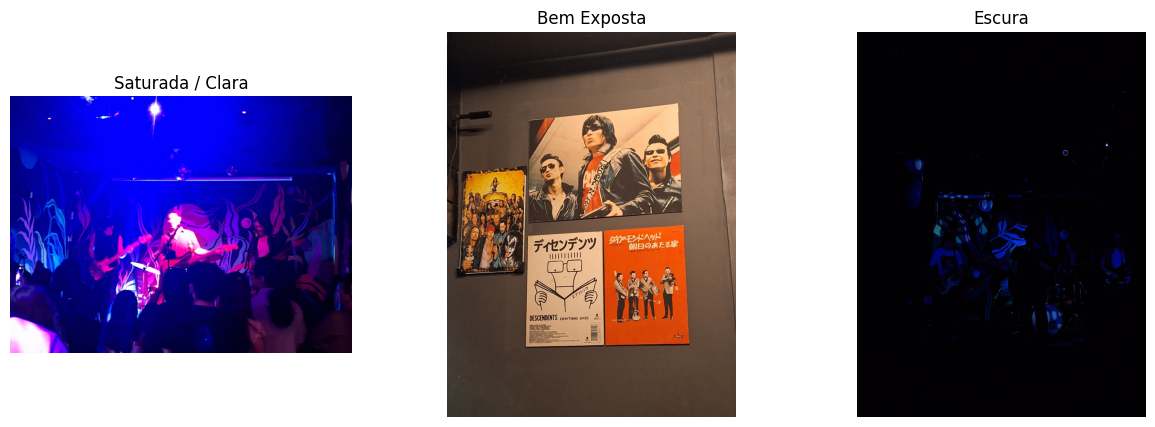

In [17]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(foto_saturada_rgb)
plt.title("Saturada / Clara")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(foto_exposta_rgb)
plt.title("Bem Exposta")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(foto_escura_rgb)
plt.title("Escura")
plt.axis('off')

plt.show()

In [18]:
def plotar_histograma_cinza(imagem_rgb, titulo):
    imagem_cinza = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2GRAY)

    histograma = cv2.calcHist([imagem_cinza], [0], None, [256], [0, 256])

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(imagem_cinza, cmap='gray')
    plt.title(f'Escala de Cinza - {titulo}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.plot(histograma, color='black')
    plt.title(f'Histograma - {titulo}')
    plt.xlabel('Intensidade do Pixel')
    plt.ylabel('Frequência')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    return imagem_cinza, histograma

#### Foto Escura

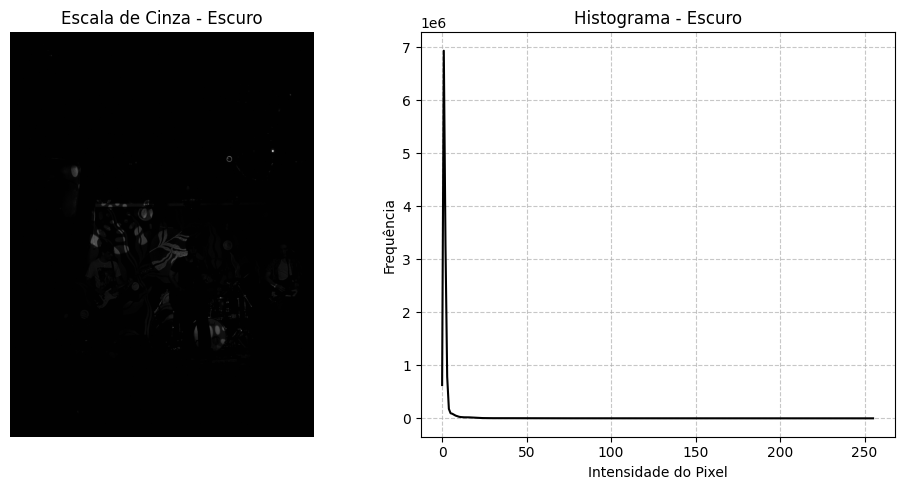

In [19]:
cinza_escura, histograma_escura = plotar_histograma_cinza(foto_escura_rgb, "Escuro")

**Diagnóstico (Foto Escura):** O histograma mostra que a maioria dos pixels está concentrada nas intensidades mais baixas (próximo de 0). Isso indica que a imagem é predominantemente escura e subexposta, com pouca variação nos tons médios e altos, resultando em perda de detalhes nas áreas escuras.

#### Foto Saturada / Clara

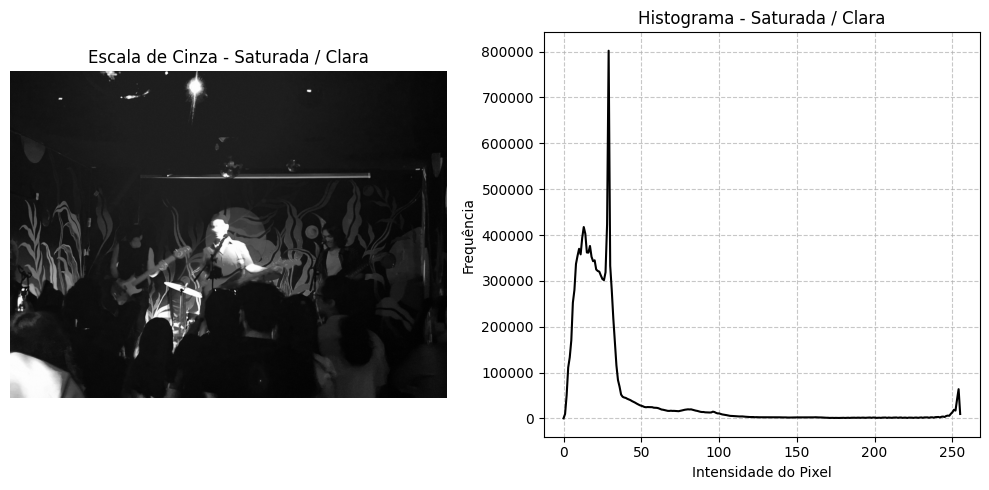

In [20]:
cinza_saturada, histograma_saturada = plotar_histograma_cinza(foto_saturada_rgb, "Saturada / Clara")

**Diagnóstico (Foto Saturada / Clara):** O histograma desta imagem mostra uma concentração de pixels nas intensidades mais altas (próximo de 255), indicando áreas muito claras ou sobreexpostas, e também uma porção considerável de pixels nas intensidades mais baixas. Isso sugere que a imagem pode estar super exposta ou ter cores altamente saturadas, resultando em perda de detalhes nas áreas claras e um contraste elevado.

#### Foto Bem Exposta

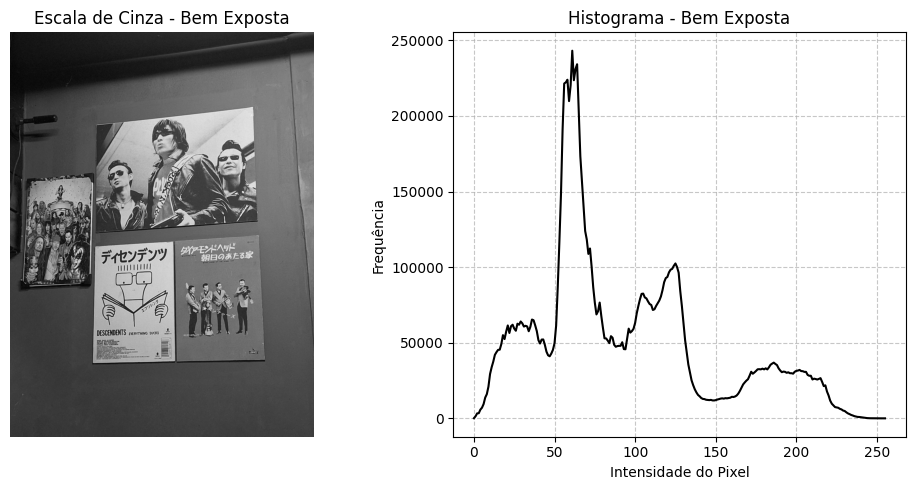

In [21]:
cinza_exposta, histograma_exposta = plotar_histograma_cinza(foto_exposta_rgb, "Bem Exposta")

In [22]:
def expandir_contraste(imagem, L=0, H=255):
    if imagem.dtype != np.uint8:
        imagem = cv2.convertScaleAbs(imagem)

    min_val = np.min(imagem)
    max_val = np.max(imagem)

    if (max_val - min_val) == 0:
        return np.full_like(imagem, fill_value=L, dtype=np.uint8)

    imagem_expandida = ((imagem - min_val) / (max_val - min_val)) * (H - L) + L
    imagem_expandida = np.clip(imagem_expandida, 0, 255).astype(np.uint8)

    return imagem_expandida

def equalizar_histograma(imagem):
    if imagem.dtype != np.uint8:
        imagem = cv2.convertScaleAbs(imagem)

    imagem_equalizada = cv2.equalizeHist(imagem)
    return imagem_equalizada

def corrigir_gamma(imagem, gamma=1.0):
    if imagem.dtype != np.uint8:
        imagem = cv2.convertScaleAbs(imagem)

    inv_gamma = 1.0 / gamma
    tabela = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")

    return cv2.LUT(imagem, tabela)

**Diagnóstico (Foto Bem Exposta):** O histograma desta imagem apresenta uma distribuição de intensidades mais equilibrada, cobrindo uma ampla gama de tons, desde as áreas mais escuras até as mais claras, sem grandes picos extremos ou cortes. Isso indica que a imagem está bem exposta, com bom contraste e detalhes preservados tanto nas sombras quanto nos realces.

#### Aplicação e Justificativa (Foto Escura)

**Justificativa:** o histograma da foto escura mostra os pixels concentrados nas intensidades baixas, sem ocupar toda a faixa de 0 a 255, ou seja, a informação de contraste existe, mas está "espremida" em uma faixa estreita de tons. A operação escolhida foi a expansão de contraste (com L=0 e H=255), pois ela apenas redistribui os valores já existentes para ocupar toda a faixa dinâmica, sem inventar novas frequências como a equalização faria. Isso melhora o contraste de forma mais suave e evita amplificar ruído em excesso, o que é mais arriscado em uma imagem que já tem pouca informação nas regiões claras.

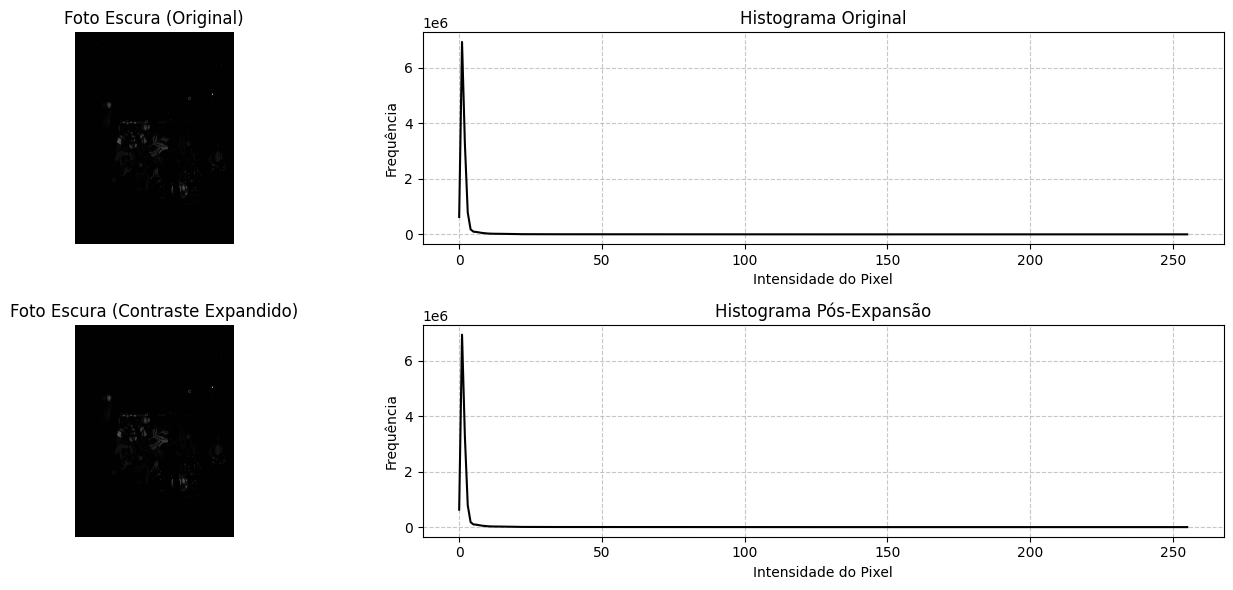

In [23]:
expandido_escura = expandir_contraste(cinza_escura, L=0, H=255)
histograma_expandido_escura = cv2.calcHist([expandido_escura], [0], None, [256], [0, 256])

plt.figure(figsize=(15, 6))

plt.subplot(2, 2, 1)
plt.imshow(cinza_escura, cmap='gray')
plt.title('Foto Escura (Original)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.plot(histograma_escura, color='black')
plt.title('Histograma Original')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(2, 2, 3)
plt.imshow(expandido_escura, cmap='gray')
plt.title('Foto Escura (Contraste Expandido)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.plot(histograma_expandido_escura, color='black')
plt.title('Histograma Pós-Expansão')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Aplicação e Justificativa (Foto Saturada / Clara)

**Justificativa:** o histograma da foto saturada/clara apresenta pixels acumulados tanto nas intensidades altas (próximo de 255, áreas estouradas) quanto nas baixas, mas já ocupando praticamente toda a faixa de 0 a 255. Por isso, uma simples expansão de contraste (esticar min-max) não traria ganho, já que o mínimo e o máximo já estão perto dos extremos. A operação escolhida foi a equalização de histograma, que redistribui as frequências de intensidade de forma mais uniforme ao longo de toda a faixa, realçando detalhes nas regiões comprimidas (tanto nas sombras quanto nos realces) sem precisar de um parâmetro manual. O próprio algoritmo (cv2.equalizeHist) calcula a transformação a partir da distribuição acumulada.

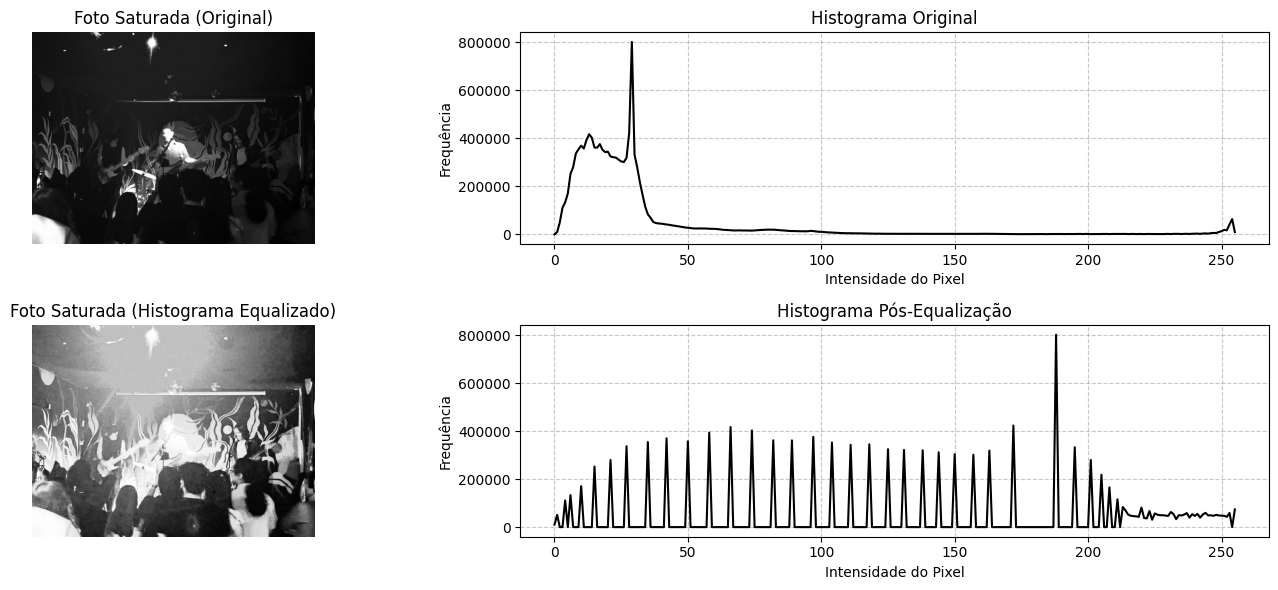

In [24]:
equalizado_saturada = equalizar_histograma(cinza_saturada)
histograma_equalizado_saturada = cv2.calcHist([equalizado_saturada], [0], None, [256], [0, 256])

plt.figure(figsize=(15, 6))

plt.subplot(2, 2, 1)
plt.imshow(cinza_saturada, cmap='gray')
plt.title('Foto Saturada (Original)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.plot(histograma_saturada, color='black')
plt.title('Histograma Original')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(2, 2, 3)
plt.imshow(equalizado_saturada, cmap='gray')
plt.title('Foto Saturada (Histograma Equalizado)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.plot(histograma_equalizado_saturada, color='black')
plt.title('Histograma Pós-Equalização')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Aplicação e Justificativa (Foto Bem Exposta)

**Justificativa:** o histograma da foto bem exposta já cobre de forma equilibrada quase toda a faixa de 0 a 255, sem grandes picos nos extremos e sem cortes (clipping). Isso indica que a imagem não precisa de correção. Ainda assim, para manter o padrão de aplicar uma operação às três imagens, foi escolhida a correção de gamma com γ = 1.0, que corresponde à função identidade (não altera nenhum pixel). O valor foi escolhido propositalmente: γ=1.0 é a forma de aplicar uma correção de gamma sem de fato distorcer uma imagem que já está bem exposta, evitando o erro comum de super-corrigir uma foto que não precisa de ajuste.

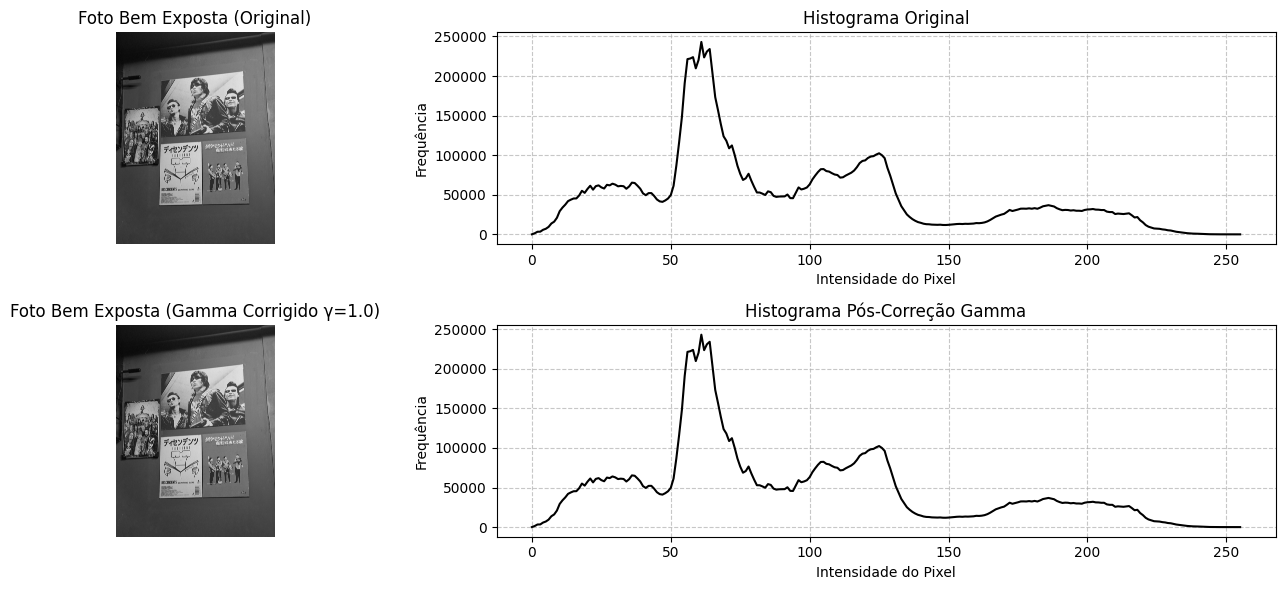

In [25]:
correcao_gamma_exposto = corrigir_gamma(cinza_exposta, gamma=1.0)
histograma_gamma_exposta = cv2.calcHist([correcao_gamma_exposto], [0], None, [256], [0, 256])

plt.figure(figsize=(15, 6))

plt.subplot(2, 2, 1)
plt.imshow(cinza_exposta, cmap='gray')
plt.title('Foto Bem Exposta (Original)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.plot(histograma_exposta, color='black')
plt.title('Histograma Original')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(2, 2, 3)
plt.imshow(correcao_gamma_exposto, cmap='gray')
plt.title('Foto Bem Exposta (Gamma Corrigido γ=1.0)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.plot(histograma_gamma_exposta, color='black')
plt.title('Histograma Pós-Correção Gamma')
plt.xlabel('Intensidade do Pixel')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Conclusão

Das três imagens, a operação que teve menos efeito na foto foi a bem exposta. Isso acontece porque seu histograma original já ocupava de forma equilibrada quase toda a faixa de intensidades (0 a 255), sem concentração excessiva em nenhuma região, ou seja, a imagem já tinha bom contraste e bons níveis antes de qualquer processamento. Como a correção de gamma foi aplicada com γ = 1.0 (a função identidade), o resultado é matematicamente igual à imagem original, o que confirma visualmente que nenhuma correção era necessária. Já nas fotos escura e saturada, os histogramas originais estavam concentrados em faixas estreitas (próximo de 0 na escura, e nos dois extremos na saturada), então a expansão de contraste e a equalização, respectivamente, provocaram mudanças visuais e estatísticas bem mais evidentes, redistribuindo os pixels e recuperando detalhes que estavam comprimidos no histograma original.